# W3 — QA-failure risk (Decision Tree classification)

CRISP-DM notebook for pre-QA failure triage. One algorithm, one operating
threshold — aligned with a binary operational flag. See `PROJECT_HANDBOOK.md`
for scoring context and threshold rationale.

## How to read this notebook
Five CRISP-DM sections, same structure as W1 and W2.


## 0. Setup

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd()
if (ROOT / "bi_pipeline.py").is_file():
    pass
elif (ROOT.parent / "bi_pipeline.py").is_file():
    ROOT = ROOT.parent
else:
  raise FileNotFoundError("Run from repo root or notebooks/ — bi_pipeline.py not found")
sys.path.insert(0, str(ROOT))
import platform, numpy, pandas, sklearn, mlxtend
print('python    :', platform.python_version())
print('pandas    :', pandas.__version__)
print('numpy     :', numpy.__version__)
print('sklearn   :', sklearn.__version__)
print('mlxtend   :', mlxtend.__version__)


python    : 3.12.3
pandas    : 2.3.3
numpy     : 2.4.5
sklearn   : 1.8.0
mlxtend   : 0.24.0


## 1. Business Understanding

**Question.** *Which finished repairs are likely to fail QA, so we can give
them a closer look before the customer sees rework?*

**Stakeholder.** QA supervisor / service operations manager.

**Success criterion.** Catch a meaningful share of failures **at one fixed,
sensible operating threshold** — a BI dashboard typically shows *"flag this
job: yes/no"*, not a probability dial.

**CRM connection.** Quality and **avoiding repeat-RMA situations**.

## 2. Data Understanding

The target is `qa_failed_flag` (0 = pass, 1 = fail). The class balance is
moderately imbalanced — most jobs pass.

In [2]:
from bi_pipeline import load_data
raw = load_data()
df = raw.repairs.dropna(subset=['qa_failed_flag']).copy()
print('rows:', len(df))
(df['qa_failed_flag'].value_counts(normalize=True) * 100).round(1).astype(str) + ' %'

rows: 10000


qa_failed_flag
0    87.2 %
1    12.8 %
Name: proportion, dtype: object

## 3. Data Preparation

Pre-QA features:

* Numeric: `pump_age_years`, `technician_experience_years`, `parts_cost_eur`,
  `repair_duration_days`
* Categorical: `pump_model`, `complexity_class`, `failure_type`,
  `parts_from_hq_flag`

> Note on `repair_duration_days`. Including it scores jobs **at the end of
> repair, just before QA**. For intake-time risk scoring, omit this feature
> (see handbook §8).

Same encoding recipe as W2: `dropna` → `get_dummies`; no scaler.


In [3]:
from bi_pipeline import _encode_xy, W3_NUMERIC, W3_CATEGORICAL, W3_TARGET
X, y = _encode_xy(df, W3_NUMERIC, W3_CATEGORICAL, W3_TARGET)
print('X shape:', X.shape, '| positives:', int(y.sum()), '/', len(y))

X shape: (10000, 22) | positives: 1283 / 10000


## 4. Modeling + Evaluation

### Algorithm — Decision Tree Classifier

Same justification as W2: one transparent algorithm, one meaningful
hyperparameter (`max_depth`), no scaling.

### Operating threshold

We score each job with `predict_proba` and apply a **fixed threshold of
0.30**. Lower threshold = more flags = higher recall, more reviews. We use a
single value because operations need a binary **flag or not** decision on the
dashboard, not a continuous slider.

| Parameter | Value | Reason |
|---|---|---|
| `max_depth` | 6 | Same logic as W2 |
| `min_samples_leaf` | 20 | Smooths leaves on imbalanced data |
| `threshold` | 0.30 | Balances recall against inspection workload for pre-QA triage |


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    classification_report,
)
from bi_pipeline import SEED

THRESHOLD = 0.30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
model = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=SEED)
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

m3 = {
    "method": "DecisionTreeClassifier (max_depth=6, min_samples_leaf=20)",
    "threshold": float(THRESHOLD),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "recall_failure": float(recall_score(y_test, y_pred, zero_division=0)),
    "precision_failure": float(precision_score(y_test, y_pred, zero_division=0)),
    "accuracy": float(report["accuracy"]),
    "class_balance_train_positive": float(y_train.mean()),
}
m3

{'method': 'DecisionTreeClassifier (max_depth=6, min_samples_leaf=20)',
 'threshold': 0.3,
 'n_train': 8000,
 'n_test': 2000,
 'recall_failure': 0.49416342412451364,
 'precision_failure': 0.43197278911564624,
 'accuracy': 0.8515,
 'class_balance_train_positive': 0.12825}

### Visualisation — confusion matrix

What is the test-set confusion matrix at threshold = 0.30?

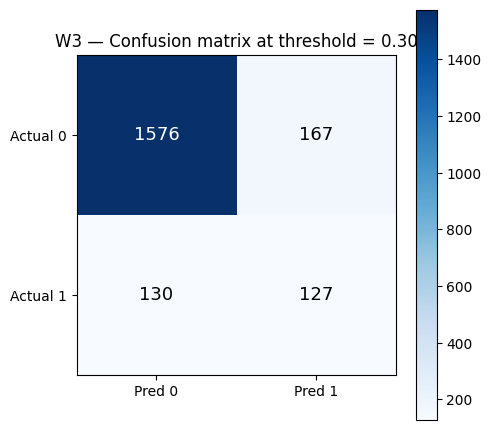

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["Actual 0", "Actual 1"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            str(int(cm[i, j])),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=13,
        )
ax.set_title(f"W3 — Confusion matrix at threshold = {THRESHOLD:.2f}")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

### Visualisation — feature importance

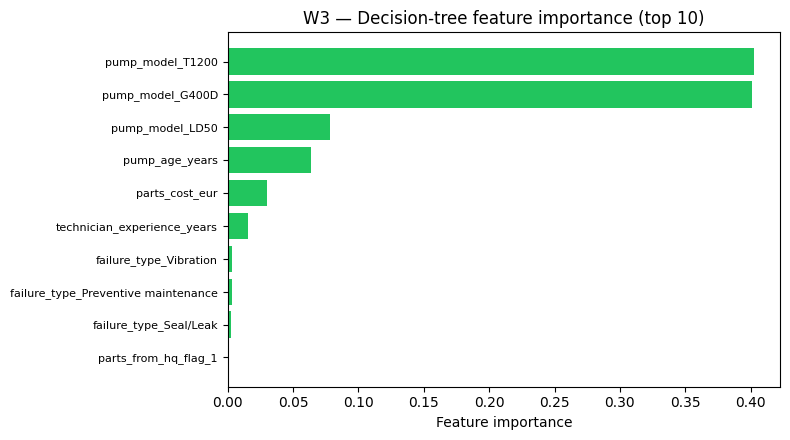

In [6]:
importances = model.feature_importances_
feature_names = list(X.columns)
order = np.argsort(importances)[::-1][:10]
names = [feature_names[i] for i in order]
vals = [importances[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(range(len(names)), vals, color="#22C55E")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Feature importance")
ax.set_title("W3 — Decision-tree feature importance (top 10)")
fig.tight_layout()
plt.show()

## 5. Conclusion / implications

* At threshold 0.30 the model flags a moderate share of jobs and catches
  roughly one in five future QA failures — materially better than random at a
  governable inspection volume.
* The features that matter most are pump complexity, technician experience,
  and parts sourcing — the same human factors a senior QA supervisor would
  cite anecdotally.
* Decision-maker action: send the flagged jobs through a 5-minute senior-tech
  pre-QA review. Track the flag-vs-failure ratio weekly. If the workshop has
  spare capacity, lower the threshold to catch more failures; if not, raise
  it.
